In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

from diffSPH.neighborhood import buildNeighborhood
from diffSPH.operations import SPHOperation
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.kernels import *
from diffSPH.plotting import visualizeParticles
from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

queryPositions, referencePositions, \
        querySupports, referenceSupports, \
        queryMasses, referenceMasses, \
        queryDensities, referenceDensities, \
        domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)


Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' took 8.85 ms  (cached)
Module sphWarpCore.operations.wp_density 414a5a1 load on device 'cuda:0' took 7.03 ms  (cached)


In [3]:
densities_warp = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    None, None,
    domain = domain, adjacency = adjacency, 
    operation = WarpOperation.Density, operationMode = OperationDirection.AllToAll,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.Gather,
)

if not warpOnly:
    densities_diffSPH = SPHOperation(
        simulationState,
        quantity = None,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Density,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )


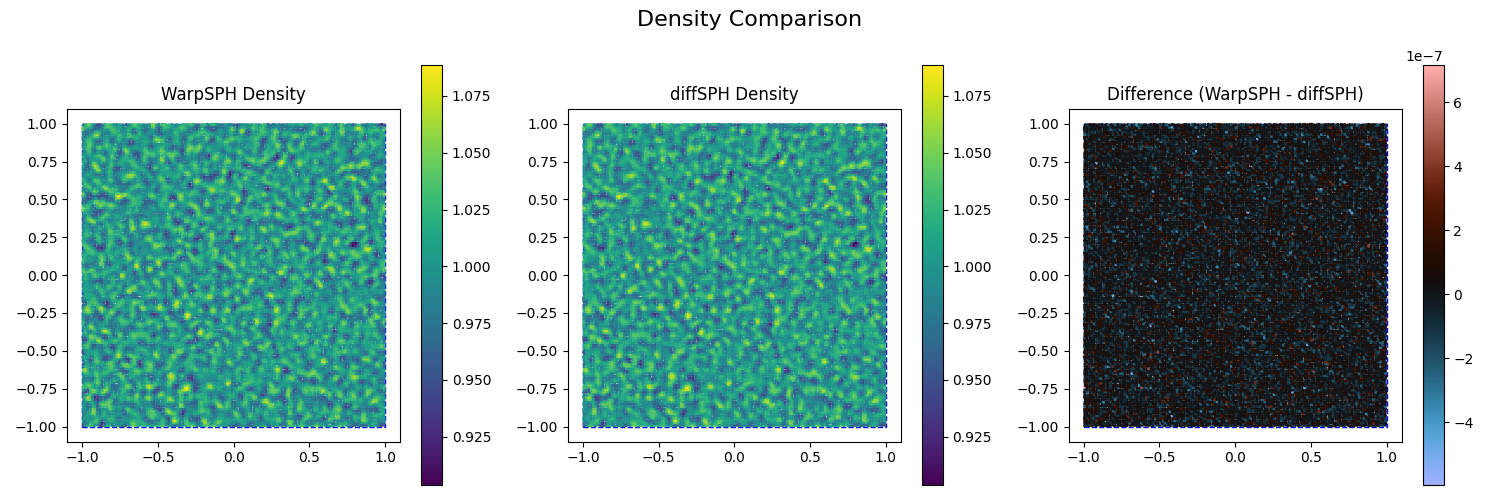

In [4]:
fig, axis = plt.subplots(1,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,5 if not warpOnly else 10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128

warpPlot = visualizeParticles(
      fig, axis[0,0],
      PlotSet(
        positions = queryPositions,
        supports = querySupports,
        masses = queryMasses,
        densities = queryDensities,
        kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long)
      ),
      quantity = densities_warp,
      kernel = KernelType.Wendland2,
      domain = domain,

      cmap = 'viridis',
      markerSize = markerSize,
      gridVisualization = gridVisualization,
      gridResolution = gridResolution,

      streamLines = False,
      plotDomain = True,
      title = "WarpSPH Density",
)

# c = axis[0,0].scatter(referencePositions[:,0].cpu(), referencePositions[:,1].cpu(), c = densities_warp.cpu(), s = markerSize)
# axis[0,0].set_title("WarpSPH Density")
# fig.colorbar(c, ax = axis[0,0])

if not warpOnly:
    diffSPHPlot = visualizeParticles(
        fig, axis[0,1],
        PlotSet(
            positions = queryPositions,
            supports = querySupports,
            masses = queryMasses,
            densities = queryDensities,
            kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long)
        ),
        quantity = densities_diffSPH,
        kernel = KernelType.Wendland2,
        domain = domain,

        cmap = 'viridis',
        markerSize = markerSize,
        gridVisualization = gridVisualization,
        gridResolution = gridResolution,

        streamLines = False,
        plotDomain = True,
        title = "diffSPH Density",
    )

    diff = (densities_warp - densities_diffSPH)
    
    differencePlot = visualizeParticles(
        fig, axis[0,2],
        PlotSet(
            positions = queryPositions,
            supports = querySupports,
            masses = queryMasses,
            densities = queryDensities,
            kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long)
        ),
        quantity = diff,
        kernel = KernelType.Wendland2,
        domain = domain,

        cmap = 'berlin',
        markerSize = markerSize,
        gridVisualization = gridVisualization,
        gridResolution = gridResolution,

        streamLines = False,
        plotDomain = True,
        title = "Difference (WarpSPH - diffSPH)",
    )

fig.suptitle("Density Comparison" if not warpOnly else "WarpSPH Density", fontsize = 16)
fig.tight_layout()
